# Data Exploration — Column Inventory
Load the NYC LL84 dataset and inspect what columns we have, their types, and completeness.

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv('../data/dataset.csv')
print(f"Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")
print()
print("All columns:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:3d}. {col}")

/var/folders/mj/1y9gngxs6v52_t9ksh10c0wh0000gn/T/ipykernel_44420/509940759.py:4: DtypeWarning: Columns (0: Postal Code, 1: Largest Property Use Type - Gross Floor Area (ft²), 2: Eligible for Certification for Report PED (Y/N), 3: ENERGY STAR Certification - Application Status, 4: Percent Electricity, 5: Natural Gas Use (therms), 6: Total (Location-Based) GHG Emissions (Metric Tons CO2e), 7: Total (Location-Based) GHG Emissions Intensity (kgCO2e/ft²), 8: Direct GHG Emissions (Metric Tons CO2e), 9: Direct GHG Emissions Intensity (kgCO2e/ft²), 10: Indirect (Location-Based) GHG Emissions (Metric Tons CO2e), 11: Indirect (Location-Based) GHG Emissions Intensity (kgCO2e/ft²), 12: Net Emissions (Metric Tons CO2e), 13: Default Values, 14: Institutional Property? (Y/N), 15: Data Quality Checker Run?, 16: Data Quality Checker - Date Run, 17: Last Modified Date - Property, 18: Last Modified Date - Electric Meters, 19: Electric Distribution Utility, 20: Last Modified Date - Gas Meters, 21: Last Mo

Rows: 103,259  |  Columns: 265

All columns:
    1. Calendar Year
    2. Property ID
    3. Property Name
    4. Parent Property ID
    5. Parent Property Name
    6. Year Ending
    7. NYC Borough, Block and Lot (BBL)
    8. NYC Building Identification Number (BIN)
    9. Address 1
   10. City
   11. Postal Code
   12. Primary Property Type - Self Selected
   13. Primary Property Type - Portfolio Manager-Calculated
   14. National Median Reference Property Type
   15. List of All Property Use Types (GFA) (ft²)
   16. Largest Property Use Type
   17. Largest Property Use Type - Gross Floor Area (ft²)
   18. 2nd Largest Property Use Type
   19. 2nd Largest Property Use Type - Gross Floor Area (ft²)
   20. 3rd Largest Property Use Type
   21. 3rd Largest Property Use Type - Gross Floor Area (ft²)
   22. Year Built
   23. Construction Status
   24. Number of Buildings
   25. Occupancy
   26. Metered Areas (Energy)
   27. Metered Areas (Water)
   28. ENERGY STAR Score
   29. National Media

In [ ]:

# Build a summary of every column: dtype, non-null count, % filled, and a sample value
summary = pd.DataFrame({
    'dtype': df.dtypes,
    'non_null': df.notna().sum(),
    'pct_filled': (df.notna().sum() / len(df) * 100).round(1),
    'sample_value': df.iloc[0]
})
summary.index.name = 'column'
pd.set_option('display.max_rows', None)
summary

In [ ]:
# Count columns by data type
print("Columns by dtype:")
print(df.dtypes.value_counts())

In [ ]:
# Highlight columns with very low fill rates (< 10%)
sparse = summary[summary['pct_filled'] < 10]
print(f"Columns with < 10% data filled: {len(sparse)}")
sparse[['pct_filled']]

In [ ]:
# Highlight columns with good fill rates (> 80%)
dense = summary[summary['pct_filled'] > 80]
print(f"Columns with > 80% data filled: {len(dense)}")
dense[['dtype', 'pct_filled']]

In [10]:
cols = {
    'type': 'Primary Property Type - Self Selected',
    'sqft': 'Largest Property Use Type - Gross Floor Area (ft²)',
    'year_built': 'Year Built',
    'num_buildings': 'Number of Buildings',
    'occupancy': 'Occupancy',
    'borough': 'Borough',
    'latitude': 'Latitude',
    'longitude': 'Longitude',
    'target': 'Site EUI (kBtu/ft²)',    
}

subset = df[list(cols.values())]
print(subset.info())
print()
print(subset.describe())
print(
    df['Site EUI (kBtu/ft²)'].describe()
)

eui = pd.to_numeric(df['Site EUI (kBtu/ft²)'], errors='coerce')
print(eui.describe())
print(f"\nMissing: {eui.isna().sum():,}")

<class 'pandas.DataFrame'>
RangeIndex: 103259 entries, 0 to 103258
Data columns (total 9 columns):
 #   Column                                              Non-Null Count   Dtype  
---  ------                                              --------------   -----  
 0   Primary Property Type - Self Selected               103259 non-null  str    
 1   Largest Property Use Type - Gross Floor Area (ft²)  103259 non-null  object 
 2   Year Built                                          103259 non-null  int64  
 3   Number of Buildings                                 103259 non-null  int64  
 4   Occupancy                                           103259 non-null  int64  
 5   Borough                                             99534 non-null   str    
 6   Latitude                                            99526 non-null   float64
 7   Longitude                                           99526 non-null   float64
 8   Site EUI (kBtu/ft²)                                 103259 non-null  str    

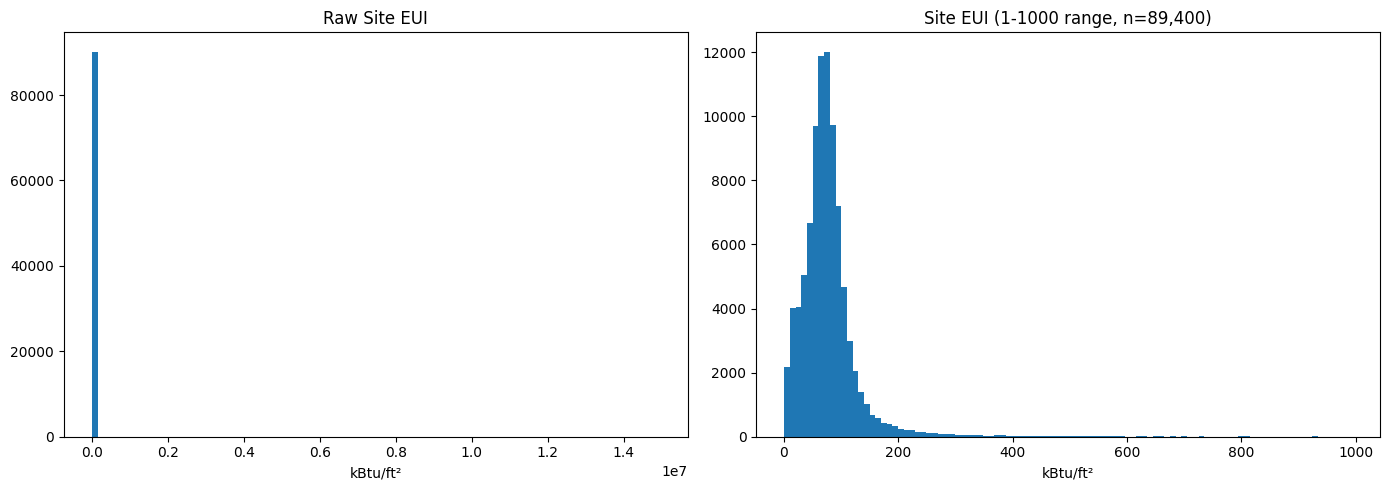

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw — you'll barely see anything useful
axes[0].hist(eui.dropna(), bins=100)
axes[0].set_title('Raw Site EUI')
axes[0].set_xlabel('kBtu/ft²')

# Filtered to reasonable range
reasonable = eui[(eui > 1) & (eui < 1000)]
axes[1].hist(reasonable, bins=100)
axes[1].set_title(f'Site EUI (1-1000 range, n={len(reasonable):,})')
axes[1].set_xlabel('kBtu/ft²')

plt.tight_layout()
plt.show()

In [ ]:
reasonable_df = df.copy()
reasonable_df['EUI'] = eui
# break the dataset to only include rows where EUI is between 1 and 1000
reasonable_df = reasonable_df[(reasonable_df['EUI'] > 1) & (reasonable_df['EUI'] < 1000)]

# Convert sqft to numeric too
# make both columns valid numeric columns, coercing errors to NaN
reasonable_df['sqft'] = pd.to_numeric(reasonable_df['Largest Property Use Type - Gross Floor Area (ft²)'], errors='coerce')
# Make column for year built numeric as well
reasonable_df['year_built'] = pd.to_numeric(reasonable_df['Year Built'], errors='coerce')

print(reasonable_df.groupby('Primary Property Type - Self Selected')['EUI'].median().sort_values(ascending=False).head(15))

print(reasonable_df.groupby('Primary Property Type - Self Selected')['EUI'].median().sort_values(ascending=True).head(15))

print(reasonable_df[['EUI', 'sqft', 'year_built']].corr())

Primary Property Type - Self Selected
Drinking Water Treatment & Distribution    834.45
Laboratory                                 274.60
Zoo                                        267.30
Wastewater Treatment Plant                 265.40
Aquarium                                   242.70
Hospital (General Medical & Surgical)      224.50
Ice/Curling Rink                           217.45
Data Center                                210.00
Veterinary Office                          196.90
Supermarket/Grocery Store                  195.40
Other - Specialty Hospital                 172.70
Food Service                               167.40
Ambulatory Surgical Center                 153.10
Food Sales                                 133.40
Other - Recreation                         132.20
Name: EUI, dtype: float64
                 EUI      sqft  year_built
EUI         1.000000  0.032662   -0.058868
sqft        0.032662  1.000000    0.080198
year_built -0.058868  0.080198    1.000000


In [15]:
print(reasonable_df.groupby('Primary Property Type - Self Selected')['EUI'].median().sort_values(ascending=True).head(15))

Primary Property Type - Self Selected
Fast Food Restaurant               4.10
Parking                           10.90
Self-Storage Facility             13.80
Lifestyle Center                  15.00
Prison/Incarceration              26.20
Non-Refrigerated Warehouse        34.00
Distribution Center               37.05
Manufacturing/Industrial Plant    46.15
Mailing Center/Post Office        46.90
Other - Utility                   50.00
Pre-school/Daycare                50.10
Worship Facility                  51.10
Vehicle Dealership                52.05
Indoor Arena                      53.20
Bank Branch                       53.70
Name: EUI, dtype: float64
